# Evaluación del modelo

Pestaña de métricas del modelo seleccionado: **regresión logística sobre WoE, sin tratamiento del
desbalance**.

La lógica vive en `model_evaluation.py`. Este notebook la importa y aporta la narrativa y las
visualizaciones, sin duplicar una sola línea de cálculo.

## El orden, y por qué no es el de la hoja de ruta

La hoja de ruta numeraba: 6 estrés temporal, 7 calibración, 8 fairness, 9 test final. Ese orden
**abre el conjunto de prueba en la etapa 6 y lo vuelve a abrir en la 9**.

El test se mira una sola vez. Mirarlo, ajustar algo y volver a mirarlo lo convierte en un segundo
conjunto de validación, y la cifra que se reporta deja de ser una estimación honesta.

Así que todo lo decidible sin él se decide antes, sobre **predicciones fuera de fold**: cada una la
emitió un modelo que no había visto ese registro.

| | Sobre qué se decide |
|---|---|
| 1. Calibración | Fuera de fold |
| 2. Fairness | Fuera de fold |
| 3. Umbral | Fuera de fold |
| 4. Scorecard | Coeficientes, sin datos nuevos |
| 5. **Test final** | **El test, una sola vez** |

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd()))
import ft_engineering as fe
import model_evaluation as ev

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)

# El artefacto ya trae la ingenieria dentro: predice desde registros crudos.
modelo = joblib.load(fe.RUTA_MODELOS / 'modelo_seleccionado.joblib')
tr = ev.cargar_particion('estratificado', 'train')
X, y = tr.drop(columns=[fe.TARGET]), (1 - tr[fe.TARGET]).values

print('Modelo   :', [n for n, _ in modelo.steps])
print('Train    :', X.shape, f'| mora {y.mean()*100:.2f}%')

# Predicciones fuera de fold: la base de todo lo que se decide sin el test.
oof = ev.predicciones_fuera_de_fold(modelo, X, y)
print('Fuera de fold:', (~np.isnan(oof)).sum(), 'predicciones')

08:42:30 | INFO    | Configuracion cargada desde config.json


Modelo   : ['caracteristicas', 'modelo']
Train    : (8610, 32) | mora 4.75%


Fuera de fold: 8610 predicciones


## 1. Calibración

Discriminación y calibración son **propiedades independientes**. Un modelo puede ordenar perfecto y
estar pésimo calibrado.

Importa porque la probabilidad de incumplimiento entra al cálculo de provisiones: mal calibrada
significa provisionar mal, que es un problema contable antes que estadístico.

Se agrupa por cuantiles y no en intervalos fijos: las probabilidades se concentran cerca de cero, y
con intervalos de igual anchura casi todo caería en el primero.

Brier 0.04371 | ECE 0.00812
Probabilidad media predicha 0.04742 vs mora observada 0.0475 (sesgo -8e-05)


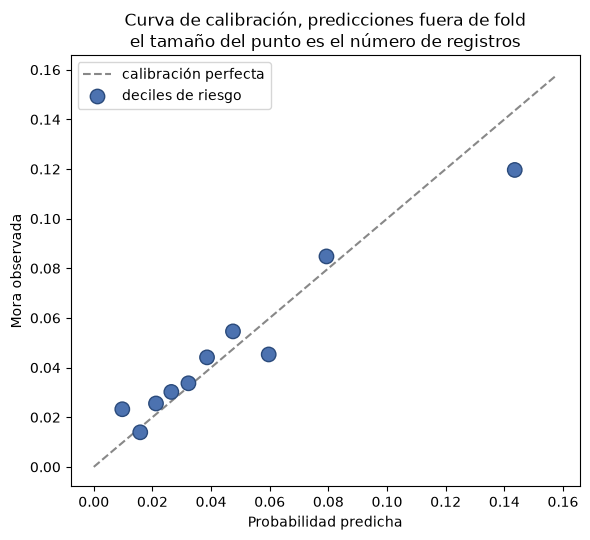

,grupo,n,predicha,observada,diferencia
0,0,861,0.00973,0.02323,-0.01350
1,1,861,0.01585,0.01394,0.00192
2,2,861,0.02122,0.02555,-0.00433
3,3,861,0.02645,0.03020,-0.00374
4,4,861,0.03228,0.03368,-0.00140
5,5,861,0.03862,0.04413,-0.00552
6,6,861,0.04747,0.05459,-0.00712
7,7,861,0.05965,0.04530,0.01435
8,8,861,0.07935,0.08479,-0.00544
9,9,861,0.14355,0.11963,0.02392


In [2]:
cal = ev.evaluar_calibracion(y, oof)
curva = pd.DataFrame(cal['curva'])

print(f"Brier {cal['brier']} | ECE {cal['ece']}")
print(f"Probabilidad media predicha {cal['prob_media_predicha']} "
      f"vs mora observada {cal['tasa_observada']} (sesgo {cal['sesgo_global']:+})")

fig, ax = plt.subplots(figsize=(6, 5.5))
lim = curva[['predicha', 'observada']].to_numpy().max() * 1.1
ax.plot([0, lim], [0, lim], ls='--', c='#888', label='calibración perfecta')
ax.scatter(curva['predicha'], curva['observada'], s=curva['n'] / 8,
           c='#4C72B0', edgecolor='#2A4A7B', zorder=3, label='deciles de riesgo')
ax.set_xlabel('Probabilidad predicha'); ax.set_ylabel('Mora observada')
ax.set_title('Curva de calibración, predicciones fuera de fold\n'
             'el tamaño del punto es el número de registros')
ax.legend(); fig.tight_layout(); plt.show()

display(curva)

**No hace falta corregirla.** El sesgo global es de ocho diezmilésimas y el ECE queda en 0,00812.

Es el pago directo de haber elegido *ninguno* en el tratamiento del desbalance: `class_weight` y
SMOTE dejaban un Brier **cinco veces peor** y habrían obligado a un paso de Platt o isotónica.
Recalibrar un modelo ya calibrado solo añadiría varianza.

Los dos deciles extremos se separan algo más de la diagonal, que es lo esperable: son las colas,
donde hay menos eventos para estimar.

## 2. Punto de operación

El umbral por defecto de 0,5 **no sirve aquí**: sin reponderar clases el modelo casi nunca lo
supera, así que no rechazaría a nadie. No es un defecto del modelo, es que 0,5 no significa nada
cuando la tasa base es 4,75%.

El criterio es el **volumen de rechazo**, no la probabilidad: se elige el umbral que rechaza el
mismo porcentaje que la regla heurística, para que la comparación sea a igual coste comercial.

In [3]:
umbral = ev.elegir_umbral(y, oof)
for k, v in umbral.items():
    print(f'  {k:24s} {v}')

  umbral                   0.0661
  criterio                 cuantil que rechaza el 20.9% de las solicitudes, el mismo volumen que la regla heuristica
  pct_rechazado            20.91
  recall                   0.4328
  precision                0.0983
  tasa_mora_aprobados      0.0341


## 3. Fairness

Se miden tasa de rechazo y tasas de error **por grupo**, no solo el AUC global: un modelo puede
tener buen AUC y aun así equivocarse de forma sistemática en un subgrupo.

Dos familias de métrica:

- **Paridad demográfica**: misma tasa de rechazo entre grupos.
- **Igualdad de opciones**: mismas tasas de acierto y falsa alarma **dentro** de cada clase real.

Las dos rara vez se cumplen a la vez cuando la tasa base difiere entre grupos, que es el caso. La
lectura correcta no es exigir que ambas den cero, sino comprobar que la diferencia sea **explicable
por riesgo** y no por pertenencia al grupo.

=== tipo_laboral ===
        grupo    n  tasa_base  tasa_rechazo    tpr    fpr  auc_pr
     Empleado 5427     0.0431        0.1861 0.4060 0.1762  0.1395
Independiente 3183     0.0550        0.2482 0.4686 0.2354  0.1295
  brecha de rechazo 0.0621 | brecha de riesgo real 0.0119

=== edad ===
grupo    n  tasa_base  tasa_rechazo    tpr    fpr  auc_pr
18-30 1464     0.0676        0.4194 0.6667 0.4015  0.1984
31-45 3830     0.0480        0.2251 0.4130 0.2156  0.1122
46-60 2529     0.0364        0.1020 0.2935 0.0948  0.1292
  60+  787     0.0432        0.0839 0.2353 0.0770  0.0731
  brecha de rechazo 0.3355 | brecha de riesgo real 0.0312



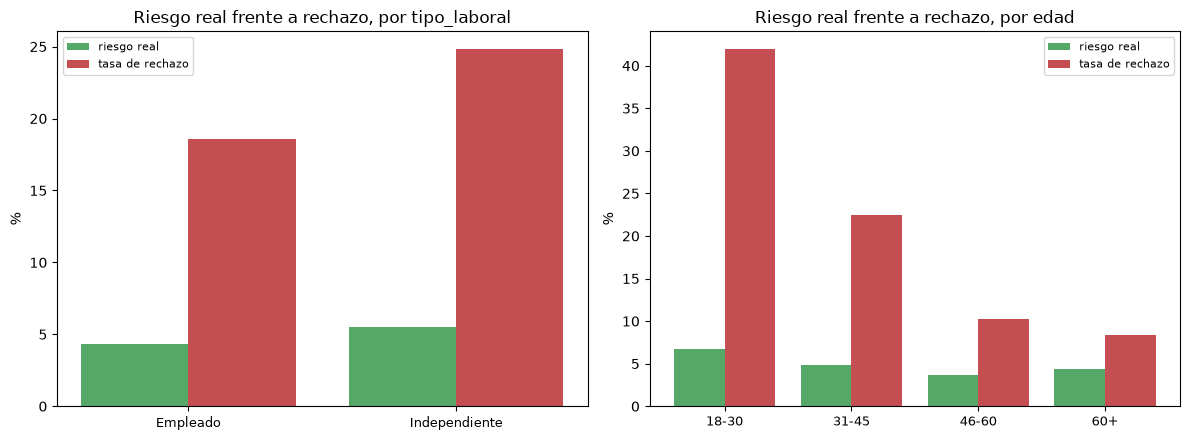

In [4]:
ejes = {'tipo_laboral': tr['tipo_laboral'],
        'edad': ev.tramos_edad(tr['edad_cliente'])}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (nombre, grupo) in zip(axes, ejes.items()):
    tabla = ev.metricas_por_grupo(y, oof, grupo, umbral['umbral'])
    resumen = ev.resumen_fairness(tabla)
    print(f'=== {nombre} ===')
    print(tabla.to_string(index=False))
    print(f"  brecha de rechazo {resumen['paridad_demografica']} "
          f"| brecha de riesgo real {resumen['brecha_tasa_base']}\n")

    x = np.arange(len(tabla))
    ax.bar(x - 0.2, tabla['tasa_base'] * 100, 0.4, label='riesgo real',
           color='#55A868')
    ax.bar(x + 0.2, tabla['tasa_rechazo'] * 100, 0.4, label='tasa de rechazo',
           color='#C44E52')
    ax.set_xticks(x); ax.set_xticklabels(tabla['grupo'], fontsize=9)
    ax.set_ylabel('%'); ax.set_title(f'Riesgo real frente a rechazo, por {nombre}')
    ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Dos hallazgos, y ninguno es cosmético.**

`tipo_laboral` se **retiró del modelo** en la selección de variables. Aun así, los independientes
son rechazados 6,2 puntos más que los empleados, cuando su riesgo real solo es 1,2 puntos mayor.
La brecha de rechazo es **cinco veces** la de riesgo. Retirar la variable no eliminó el sesgo,
exactamente como se advirtió al decidirlo: otras variables actúan de *proxy* de la informalidad
laboral. Queda medido, no supuesto.

`edad_cliente` **sí está en el modelo**, y la brecha es mucho mayor: los jóvenes son rechazados
cinco veces más que los mayores cuando su riesgo real es 1,6 veces mayor. La brecha de igualdad de
opciones llega a 43 puntos.

**Se documenta sin corregirlo, y es deliberado.** Las opciones son umbrales por grupo, retirar la
edad a costa de rendimiento, o asumirlo con justificación explícita. Ninguna es una elección que
corresponda al modelador tomar en solitario: es una decisión de negocio.

## 4. Scorecard

Traduce el modelo a una **tabla de puntos por tramo**, que es el formato con el que un analista
justifica una negación ante el cliente y ante el supervisor. Más puntos significan menos riesgo.

Escala convencional del sector: PDO 20, base 600 a *odds* 20:1.

Se verifica que la tabla **reproduce la predicción del modelo**. Si no lo hiciera, el analista
estaría viendo una tabla que no representa lo que decide el sistema.

In [5]:
from sklearn.base import clone

ajustado = clone(modelo).fit(X, y)
sc = ev.construir_scorecard(ajustado)
chequeo = ev.verificar_scorecard(ajustado, X, sc)

print(f"Escala: {sc['escala']}")
print(f"Puntaje base {sc['puntos_base']} | puntos por tramo entre {sc['rango_tabla']}")
print(f"Puntajes observados en train: {chequeo['puntaje_min']} a "
      f"{chequeo['puntaje_max']} (medio {chequeo['puntaje_medio']})")
print(f"Reproduce la prediccion del modelo: {chequeo['coincide']} "
      f"(error maximo {chequeo['error_max_probabilidad']:.2e})")

tabla_sc = pd.DataFrame(sc['tabla'])
display(tabla_sc[tabla_sc['variable'] == 'puntaje_datacredito'][['tramo', 'woe', 'puntos']])
display(pd.DataFrame(sc['ajustes_continuos']))

Escala: {'pdo': 20, 'score_base': 600, 'odds_base': 20.0, 'factor': 28.8539, 'offset': 513.5614}
Puntaje base 601 | puntos por tramo entre [6, 81]
Puntajes observados en train: 464 a 767 (medio 608)
Reproduce la prediccion del modelo: True (error maximo 2.22e-16)


,tramo,woe,puntos
0,"(-inf, 700.0]",1.1914,40
1,"(700.0, 750.0]",0.5455,55
2,"(750.0, 800.0]",-0.0890,69
3,"(800.0, inf]",-0.4191,76
4,SIN_DATO,0.4174,57


,variable,coeficiente,puntos_por_unidad
0,esc_capital_prestado,0.1548,-4.47
1,esc_cuota_pactada,0.0461,-1.33
2,esc_salario_cliente,0.0748,-2.16
3,esc_total_otros_prestamos,-0.0527,1.52
4,edad_cliente_corregida,0.3523,-10.17
5,salario_cliente_corregido,-0.0305,0.88
6,tendencia_ingresos_reconstruida,-3.9728,114.63
7,total_otros_prestamos_sospechoso,0.3493,-10.08


Solo las 9 variables WoE se tabulan por tramo. Las 4 monetarias escaladas son continuas y entran
como ajuste sobre el puntaje, no como fila de la tabla. Un scorecard completo exigiría
discretizarlas también, a costa de perder resolución.

## 5. Evaluación final

Aquí se abre el conjunto de prueba, **una sola vez**, con el modelo elegido y el umbral ya fijado.

Se evalúa también el **piso heurístico sobre el mismo conjunto**. Sin eso la comparación sería
inválida: el AUC-PR depende fuertemente de la tasa base, y la de cada test difiere (4,74% frente a
3,20%). Comparar el modelo en test contra el piso medido en train mezclaría dos poblaciones y haría
parecer que el modelo empeora cuando lo que cambió fue la proporción de eventos.

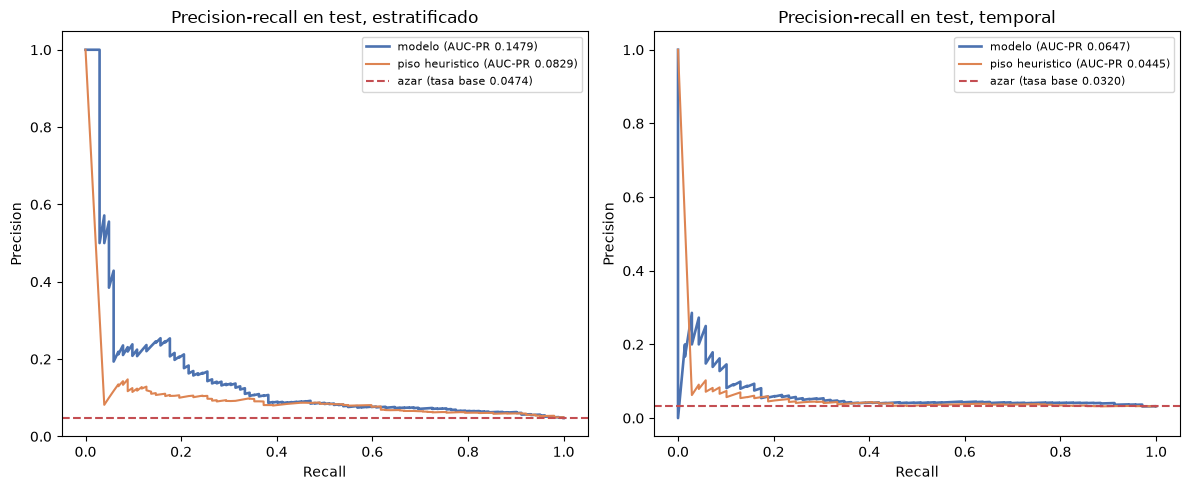

,particion,n,eventos,auc_pr,lift,ks,gini,brier,piso,lift_piso,ventaja
0,estratificado,2153,102,0.1479,3.12,0.2742,0.3697,0.04337,0.0829,1.75,1.78
1,temporal,2154,69,0.0647,2.02,0.2026,0.2415,0.03332,0.0445,1.39,1.45


In [6]:
from sklearn.metrics import precision_recall_curve

finales, filas = {}, []
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, particion in zip(axes, ['estratificado', 'temporal']):
    r = ev.evaluacion_final(modelo, particion, umbral['umbral'],
                            devolver_predicciones=True)
    finales[particion] = r
    m, piso = r['metricas'], r['piso_en_el_mismo_test']
    filas.append({
        'particion': particion, 'n': r['n_test'], 'eventos': r['eventos_test'],
        'auc_pr': m['auc_pr'], 'lift': m['lift_vs_azar'],
        'ks': m['ks'], 'gini': m['gini'], 'brier': m['brier'],
        'piso': piso['auc_pr'], 'lift_piso': piso['lift_vs_azar'],
        'ventaja': r['ventaja_sobre_el_piso'],
    })

    y_te, p_te = r['_y_test'], r['_p_test']
    pr, rc, _ = precision_recall_curve(y_te, p_te)
    ax.plot(rc, pr, lw=1.9, c='#4C72B0',
            label=f"modelo (AUC-PR {m['auc_pr']:.4f})")

    # El piso heuristico sobre el MISMO conjunto: el score como ordenador.
    # La variable se lee del contrato (ev.hm.VARIABLE_REGLA), no se escribe a mano.
    te = ev.cargar_particion(particion, 'test')
    score = te[ev.hm.VARIABLE_REGLA]
    orden = (-score).fillna(-score.min())
    pr_h, rc_h, _ = precision_recall_curve(y_te, orden)
    ax.plot(rc_h, pr_h, lw=1.5, c='#DD8452', ls='-',
            label=f"piso heuristico (AUC-PR {piso['auc_pr']:.4f})")

    ax.axhline(m['tasa_base'], ls='--', c='#C44E52',
               label=f"azar (tasa base {m['tasa_base']:.4f})")
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'Precision-recall en test, {particion}')
    ax.legend(fontsize=8)

fig.tight_layout(); plt.show()
display(pd.DataFrame(filas))

**El modelo supera al piso en las dos particiones**, así que pasa la prueba de estrés temporal. Su
ventaja cae de 1,78× a 1,45×: degrada bajo desplazamiento temporal, pero sigue aportando.

**Dos limitaciones que hay que declarar.**

*KS queda por debajo de 0,30*, el umbral que se considera utilizable en un scorecard. El modelo
aporta sobre la regla, pero no alcanza el estándar del sector para operar sin supervisión.

*El umbral fijo no se sostiene cuando la población se desplaza.* En el test temporal, el mismo
umbral rechaza el 33,3% en lugar del 21%. Es exactamente la señal que tendrá que vigilar
`model_monitoring.py`.

In [7]:
print('=== EL UMBRAL NO SE SOSTIENE ENTRE POBLACIONES ===')
for p, r in finales.items():
    m = r['metricas']
    print(f"  {p:14s} rechaza {m['pct_marcado']:5.1f}% | "
          f"captura {m['recall']*100:5.1f}% de la mora | "
          f"precision {m['precision']*100:5.2f}%")
print(f"  {'fuera de fold':14s} rechaza {umbral['pct_rechazado']:5.1f}% | "
      f"captura {umbral['recall']*100:5.1f}% de la mora | "
      f"precision {umbral['precision']*100:5.2f}%")

print('\n=== MADUREZ INCOMPLETA ===')
for p, r in finales.items():
    if 'solo_maduros' in r:
        sm = r['solo_maduros']
        print(f"  {p:14s} {r['madurez_incompleta_pct']:4.1f}% sin vencer | "
              f"solo vencidos: {sm['n']} registros, {sm['eventos']} eventos, "
              f"AUC-PR {sm['metricas']['auc_pr']} (lift {sm['metricas']['lift_vs_azar']}x)")

=== EL UMBRAL NO SE SOSTIENE ENTRE POBLACIONES ===
  estratificado  rechaza  21.6% | captura  40.2% de la mora | precision  8.84%
  temporal       rechaza  33.3% | captura  42.0% de la mora | precision  4.04%
  fuera de fold  rechaza  20.9% | captura  43.3% de la mora | precision  9.83%

=== MADUREZ INCOMPLETA ===
  estratificado  20.2% sin vencer | solo vencidos: 1718 registros, 75 eventos, AUC-PR 0.0957 (lift 2.19x)
  temporal       53.4% sin vencer | solo vencidos: 1003 registros, 21 eventos, AUC-PR 0.0358 (lift 1.71x)


## Cierre

| | Estratificado | Temporal |
|---|---|---|
| AUC-PR del modelo | 0,1479 | 0,0647 |
| AUC-PR del piso, mismo test | 0,0829 | 0,0445 |
| **Ventaja sobre el piso** | **1,78×** | **1,45×** |

El modelo está evaluado, calibrado, auditado en *fairness* y traducido a scorecard. **El conjunto de
prueba se abrió una sola vez.**

Lo que queda pendiente y este notebook deja preparado:

- `model_deploy.py` cargará el mismo artefacto y aplicará el umbral fijado aquí.
- `model_monitoring.py` vigilará el desplazamiento de población que ya se detectó: un umbral fijo
  pasa de rechazar el 21% al 33,3% entre poblaciones distintas.